# Brazilian E-Commerce — Exploratory Data Analysis

> **Olist Brazilian E-Commerce Dataset**

This notebook presents a structured exploratory analysis of the Brazilian E-Commerce public dataset by Olist.

The analysis is designed around one main question:

> **What factors are associated with order delivery time, and what information can be used to support delivery-time prediction?**

Along the way, the notebook also examines customer behavior, geography, order characteristics, payments, reviews, sellers, and temporal patterns. These analyses provide context for the downstream machine-learning experiments documented in the project README.

### Analytical workflow

**Raw Olist tables → Data quality → Order-level dataset → Exploratory analysis → Feature insights → ML-ready conclusions**

## 1. Project Scope & Analytical Questions

The original exploration covered several business questions. For the final presentation, they are grouped into a smaller set of themes so the notebook remains focused and readable.

### Customer & geography
- Where do most orders come from?
- Which states/cities show different customer or delivery behavior?
- What does repeat-purchase behavior look like?

### Orders & commerce
- How are order value, freight, and item count distributed?
- Which product categories and seller locations are most active?
- How do customers pay?

### Delivery
- How long do delivered orders take?
- How different is actual delivery from the promised date?
- What proportion of orders are delivered late?
- Which customer/geographic/order characteristics are associated with delivery time?

### Temporal behavior
- When do customers place orders?
- Are there visible month, weekday, or hour patterns?

## 2. Imports & Configuration

The notebook keeps configuration in one place and uses a small set of reusable plotting conventions. Warnings are not globally suppressed so that unexpected runtime issues remain visible.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_DIR = Path("data")

## 3. Load the Olist Tables

Olist distributes the dataset across multiple relational tables. We keep the original tables separate initially and combine only the information required for each analytical task.

In [3]:
cust_df = pd.read_csv(DATA_DIR / "olist_customers_dataset.csv")
geoloc_df = pd.read_csv(DATA_DIR / "olist_geolocation_dataset.csv")
order_items_df = pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv")
order_payments_df = pd.read_csv(DATA_DIR / "olist_order_payments_dataset.csv")
order_reviews_df = pd.read_csv(DATA_DIR / "olist_order_reviews_dataset.csv")
orders_df = pd.read_csv(DATA_DIR / "olist_orders_dataset.csv")
products_df = pd.read_csv(DATA_DIR / "olist_products_dataset.csv")
sellers_df = pd.read_csv(DATA_DIR / "olist_sellers_dataset.csv")
product_cat_name_trans_df = pd.read_csv(DATA_DIR / "product_category_name_translation.csv")

raw_tables = {
    "customers": cust_df,
    "geolocation": geoloc_df,
    "order_items": order_items_df,
    "order_payments": order_payments_df,
    "order_reviews": order_reviews_df,
    "orders": orders_df,
    "products": products_df,
    "sellers": sellers_df,
}

pd.DataFrame(
    {
        "table": list(raw_tables),
        "rows": [df.shape[0] for df in raw_tables.values()],
        "columns": [df.shape[1] for df in raw_tables.values()],
    }
)

,table,rows,columns
0,customers,99441,5
1,geolocation,1000163,5
2,order_items,112650,7
3,order_payments,103886,5
4,order_reviews,99224,7
5,orders,99441,8
6,products,32951,9
7,sellers,3095,4


## 4. Data Quality Assessment

Before combining tables, the structure and quality of the source data are inspected. In particular, delivery-related timestamps contain missing values because not every order reached the delivered state.

In [4]:
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [5]:
missing_orders = (
    orders_df.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)
missing_orders["missing_pct"] = missing_orders["missing_count"] / len(orders_df) * 100
missing_orders.sort_values("missing_count", ascending=False)

,missing_count,missing_pct
order_delivered_customer_date,2965,2.98
order_delivered_carrier_date,1783,1.79
order_approved_at,160,0.16
order_id,0,0.00
order_purchase_timestamp,0,0.00
order_status,0,0.00
customer_id,0,0.00
order_estimated_delivery_date,0,0.00


In [6]:
order_id_duplicates = {
    "orders": orders_df["order_id"].duplicated().sum(),
    "order_items": order_items_df["order_id"].duplicated().sum(),
}
pd.Series(order_id_duplicates, name="duplicate_order_id_rows")

orders             0
order_items    13984
Name: duplicate_order_id_rows, dtype: int64

### Important granularity check

`order_id` is unique in the `orders` table but **not** in `order_items`. Multiple item rows can belong to the same order. Therefore, joining order-level and item-level tables without aggregation would duplicate orders and distort metrics such as revenue, freight, and delivery-time analysis.

The final analytical dataset will use **one row per order**.

## 5. Timestamp Preparation

Timestamp columns are converted once, early in the workflow. This makes later calculations explicit and avoids repeated parsing.

In [7]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for col in date_columns:
    orders_df[col] = pd.to_datetime(orders_df[col], errors="coerce")

orders_df[date_columns].dtypes

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

## 6. Build the Order-Level Analytical Dataset

### Why aggregate?

The project ultimately predicts delivery behavior at the **order level**, so every row must represent one order.

For item-level information:

- `total_price` = sum of item prices within an order
- `total_freight` = sum of freight values across the items in the order
- `item_count` = number of item records in the order

The freight value is treated as an item-level cost because the source table records `freight_value` for each order item.

In [8]:
item_agg = (
    order_items_df
    .groupby("order_id", as_index=False)
    .agg(
        total_price=("price", "sum"),
        total_freight=("freight_value", "sum"),
        item_count=("order_item_id", "count"),
    )
)

orders_customers_df = orders_df.merge(
    cust_df,
    on="customer_id",
    how="left",
    validate="one_to_one",
)

order_level_df = orders_customers_df.merge(
    item_agg,
    on="order_id",
    how="left",
    validate="one_to_one",
)

order_level_df.shape

(99441, 15)

In [9]:
# Validate the intended granularity: exactly one row per order.
assert not order_level_df["order_id"].duplicated().any()

order_level_df[[
    "order_id", "customer_id", "customer_unique_id", "order_status",
    "customer_city", "customer_state", "total_price", "total_freight", "item_count"
]].head()

,order_id,customer_id,customer_unique_id,order_status,customer_city,customer_state,total_price,total_freight,item_count
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,delivered,sao paulo,SP,29.99,8.72,1.00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,delivered,barreiras,BA,118.70,22.76,1.00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,delivered,vianopolis,GO,159.90,19.22,1.00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,delivered,sao goncalo do amarante,RN,45.00,27.20,1.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,delivered,santo andre,SP,19.90,8.72,1.00


### Dataset after aggregation

At this point, `order_level_df` is the main table used throughout the order and delivery analysis. Item-level analyses are performed separately when the question requires products or sellers.

In [10]:
order_level_df.isna().sum().sort_values(ascending=False).to_frame("missing_count").head(10)

,missing_count
order_delivered_customer_date,2965
order_delivered_carrier_date,1783
total_freight,775
item_count,775
total_price,775
order_approved_at,160
order_status,0
order_purchase_timestamp,0
order_id,0
customer_id,0


## 7. Order Status & Analytical Eligibility

Not every order can be used for delivery-time analysis. Actual delivery time requires both the purchase timestamp and the customer-delivery timestamp.

This distinction matters because removing missing delivery timestamps blindly would mix a **data-quality decision** with a **business-state decision**. Instead, eligibility is defined explicitly for each delivery analysis.

In [11]:
status_summary = (
    order_level_df["order_status"]
    .value_counts(dropna=False)
    .rename_axis("order_status")
    .reset_index(name="orders")
)
status_summary["percentage"] = status_summary["orders"] / len(order_level_df) * 100
status_summary

,order_status,orders,percentage
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


In [12]:
delivered_df = order_level_df.loc[
    order_level_df["order_delivered_customer_date"].notna()
].copy()

len(delivered_df), len(order_level_df)

(96476, 99441)

# 8. Customer & Geographic Analysis

These analyses describe where orders come from and how customer behavior varies geographically. Geographic variables are later considered as candidate predictors for delivery time.

## 8.1 Which cities place the most orders?

Because city names are highly numerous, the final presentation focuses on the top cities by order volume rather than producing an unreadable table of every city.

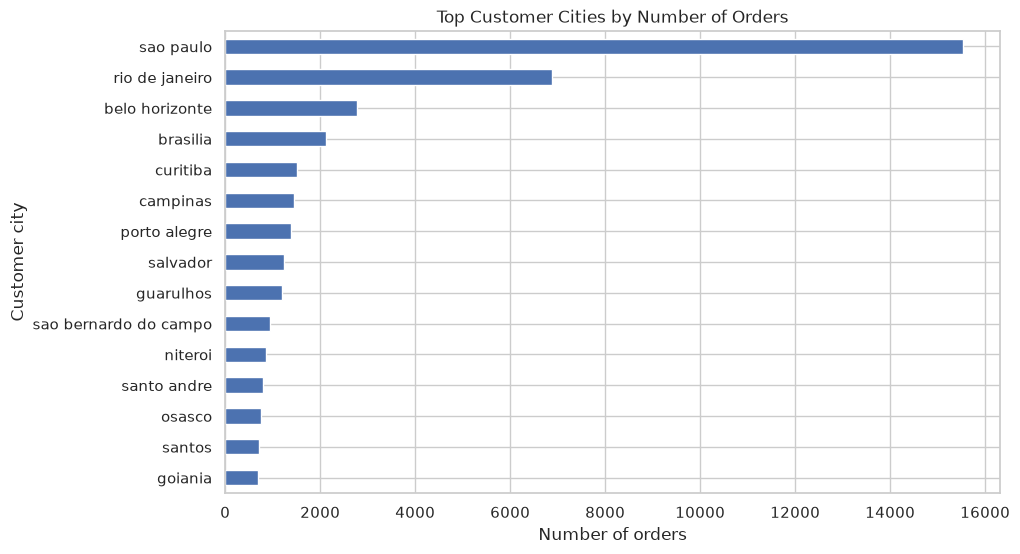

In [13]:
top_cities = (
    order_level_df["customer_city"]
    .value_counts()
    .head(15)
    .sort_values()
)

top_cities.plot(kind="barh", figsize=(10, 6))
plt.title("Top Customer Cities by Number of Orders")
plt.xlabel("Number of orders")
plt.ylabel("Customer city")
plt.show()

**Insight:** Order activity is concentrated in a relatively small number of cities. This makes geography a potentially useful descriptive feature, but city-level conclusions should account for unequal sample sizes.

## 8.2 Order Volume by State

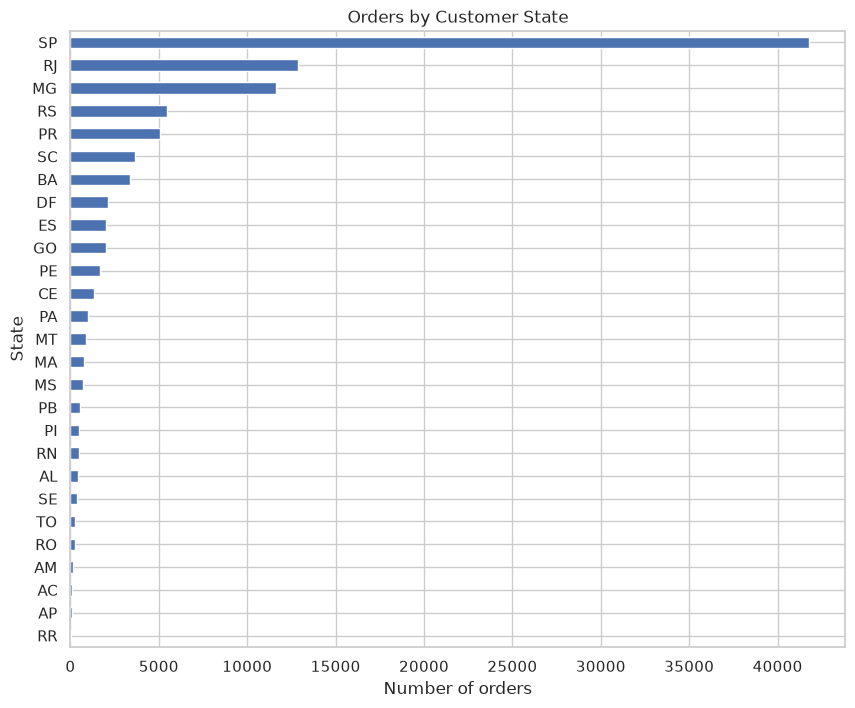

In [14]:
state_orders = order_level_df["customer_state"].value_counts().sort_values()
state_orders.plot(kind="barh", figsize=(10, 8))
plt.title("Orders by Customer State")
plt.xlabel("Number of orders")
plt.ylabel("State")
plt.show()

## 8.3 Repeat Purchase Behavior

Repeat behavior is calculated using `customer_unique_id`, not `customer_id`. The distinction matters because `customer_id` identifies an order-level customer record, while `customer_unique_id` is the customer identifier appropriate for measuring repeated purchasing across orders.

In [15]:
orders_per_customer = (
    order_level_df
    .groupby("customer_unique_id")
    .size()
    .rename("order_count")
)

repeat_summary = pd.Series({
    "one_time_customers_pct": (orders_per_customer.eq(1).mean() * 100),
    "repeat_customers_pct": (orders_per_customer.gt(1).mean() * 100),
    "max_orders_by_customer": orders_per_customer.max(),
})
repeat_summary

one_time_customers_pct   96.88
repeat_customers_pct      3.12
max_orders_by_customer   17.00
dtype: float64

**Insight:** Customer behavior is strongly concentrated around one-time purchases. This is an important business characteristic of the dataset and also cautions against assuming that repeated purchasing is common.

## 8.4 Late-Delivery Rate by State

Late delivery is defined as an order delivered **after** its estimated delivery date. Only orders with both actual and estimated delivery dates are eligible.

In [16]:
delivered_df["late_delivery"] = (
    delivered_df["order_delivered_customer_date"]
    > delivered_df["order_estimated_delivery_date"]
).astype(int)

late_by_state = (
    delivered_df.groupby("customer_state")
    .agg(
        orders=("order_id", "size"),
        late_orders=("late_delivery", "sum"),
    )
)
late_by_state["late_pct"] = late_by_state["late_orders"] / late_by_state["orders"] * 100
late_by_state.sort_values("late_pct", ascending=False).head(10)

,orders,late_orders,late_pct
customer_state,,,
AL,397,95,23.93
MA,717,141,19.67
PI,476,76,15.97
CE,1279,196,15.32
SE,335,51,15.22
BA,3256,457,14.04
RJ,12353,1664,13.47
TO,274,35,12.77
PA,946,117,12.37


**Interpretation:** State-level late percentages describe the observed order population, not the population of the state. Small-volume states can show extreme percentages from relatively few orders, so volume should always be reported alongside the rate.

# 9. Order Characteristics

Order value, freight, and item count describe the operational characteristics of each order and are natural candidate features for delivery-time modeling.

In [17]:
order_level_df[["total_price", "total_freight", "item_count"]].describe().T

,count,mean,std,min,25%,50%,75%,max
total_price,"98,666.00",137.75,210.65,0.85,45.90,86.90,149.90,"13,440.00"
total_freight,"98,666.00",22.82,21.65,0.00,13.85,17.17,24.04,"1,794.96"
item_count,"98,666.00",1.14,0.54,1.00,1.00,1.00,1.00,21.00


## 9.1 Distributions

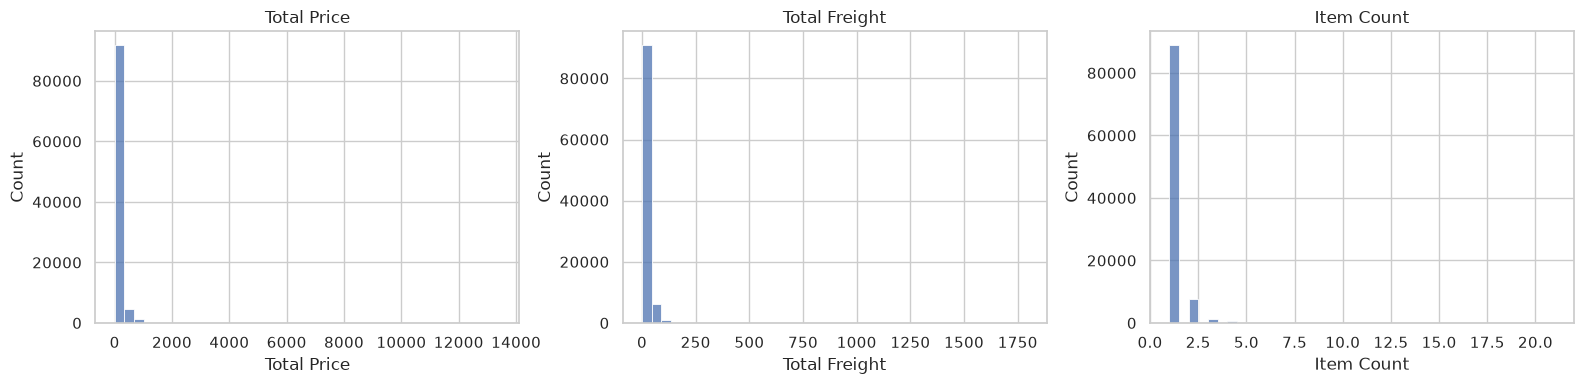

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ["total_price", "total_freight", "item_count"]):
    sns.histplot(order_level_df[col].dropna(), bins=40, ax=ax)
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel(col.replace("_", " ").title())
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

## 9.2 Outlier Inspection

Extreme values are inspected rather than automatically removed. In delivery-time prediction, unusually expensive or unusually large orders can represent genuine operational cases rather than errors.

In [19]:
q1 = order_level_df[["total_price", "total_freight", "item_count"]].quantile(0.25)
q3 = order_level_df[["total_price", "total_freight", "item_count"]].quantile(0.75)
iqr = q3 - q1

outlier_summary = pd.DataFrame({
    "Q1": q1,
    "Q3": q3,
    "lower_bound": q1 - 1.5 * iqr,
    "upper_bound": q3 + 1.5 * iqr,
})

outlier_summary["outlier_count"] = [
    ((order_level_df[col] < outlier_summary.loc[col, "lower_bound"]) |
     (order_level_df[col] > outlier_summary.loc[col, "upper_bound"])).sum()
    for col in outlier_summary.index
]

outlier_summary

,Q1,Q3,lower_bound,upper_bound,outlier_count
total_price,45.90,149.90,-110.10,305.90,7913
total_freight,13.85,24.04,-1.44,39.33,9941
item_count,1.00,1.00,1.00,1.00,9803


**Important:** Outliers are not deleted at the EDA stage merely because they are statistically unusual. Their business meaning and their effect on model metrics should be evaluated before any removal or transformation decision.

# 10. Delivery-Time Analysis

This is the core of the project. Delivery time is measured from purchase to customer delivery in days.

In [20]:
delivered_df["delivery_time_days"] = (
    delivered_df["order_delivered_customer_date"]
    - delivered_df["order_purchase_timestamp"]
).dt.total_seconds() / 86400

delivered_df["delivery_delay_days"] = (
    delivered_df["order_delivered_customer_date"]
    - delivered_df["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

delivered_df[["delivery_time_days", "delivery_delay_days"]].describe().T

,count,mean,std,min,25%,50%,75%,max
delivery_time_days,"96,476.00",12.56,9.55,0.53,6.77,10.22,15.72,209.63
delivery_delay_days,"96,476.00",-11.18,10.19,-146.02,-16.24,-11.95,-6.39,188.98


## 10.1 Delivery-Time Distribution

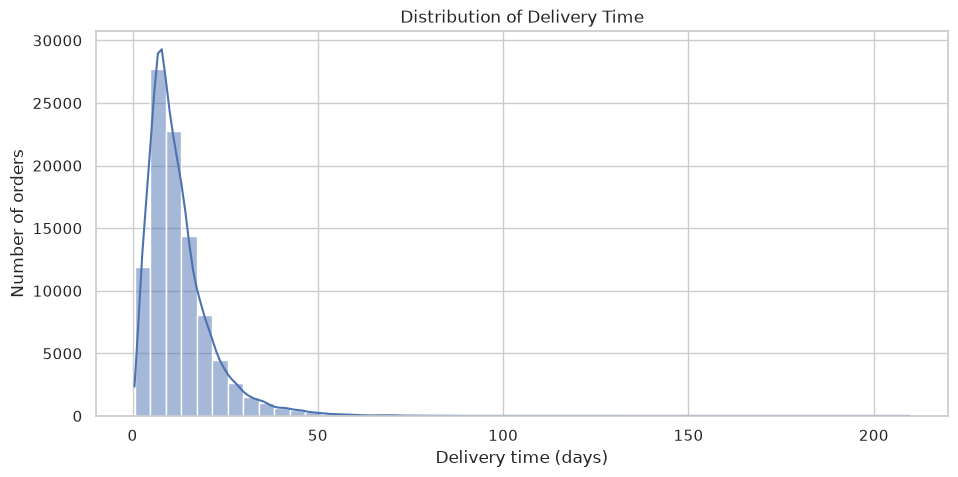

In [21]:
plt.figure(figsize=(11, 5))
sns.histplot(delivered_df["delivery_time_days"].dropna(), bins=50, kde=True)
plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery time (days)")
plt.ylabel("Number of orders")
plt.show()

In [22]:
skewness = delivered_df["delivery_time_days"].skew()
median_delivery = delivered_df["delivery_time_days"].median()
mean_delivery = delivered_df["delivery_time_days"].mean()

pd.Series({
    "mean_delivery_days": mean_delivery,
    "median_delivery_days": median_delivery,
    "skewness": skewness,
})

mean_delivery_days     12.56
median_delivery_days   10.22
skewness                3.83
dtype: float64

**Insight:** Delivery time is strongly right-skewed, meaning a relatively small number of orders take much longer than the majority. This asymmetry is important for both visualization and model evaluation, especially for metrics such as RMSE that penalize large errors more strongly.

## 10.2 Delivery-Time Box Plot

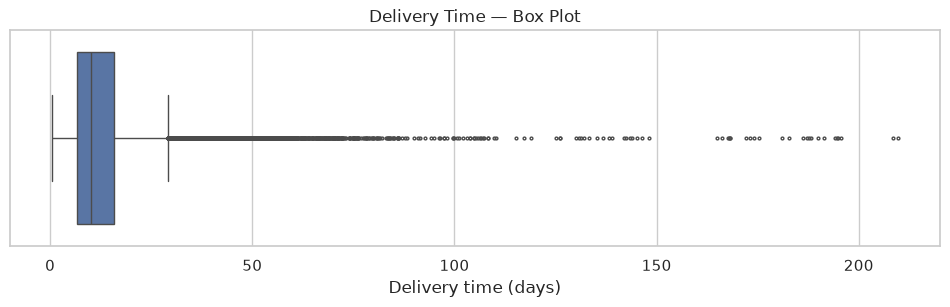

In [23]:
plt.figure(figsize=(12, 2.8))
sns.boxplot(x=delivered_df["delivery_time_days"].dropna(), fliersize=2)
plt.title("Delivery Time — Box Plot")
plt.xlabel("Delivery time (days)")
plt.show()

### How the outliers are handled

The long right tail is considered part of the real target distribution. The project later tests a logarithmic target transformation as a modeling experiment rather than silently deleting long-delivery orders.

## 10.3 Estimated Delivery Window

A useful pre-delivery feature is the time promised by the platform:

**estimated delivery window = estimated delivery date − purchase date**

Unlike the actual delivered timestamp, this variable is known when the order is placed and therefore can be considered for prediction without target leakage.

In [24]:
for df in (order_level_df, delivered_df):
    df["estimated_delivery_window_days"] = (
        df["order_estimated_delivery_date"] - df["order_purchase_timestamp"]
    ).dt.total_seconds() / 86400

pd.Series({
    "mean_window_days": order_level_df["estimated_delivery_window_days"].mean(),
    "median_window_days": order_level_df["estimated_delivery_window_days"].median(),
}).to_frame("value")

,value
mean_window_days,23.77
median_window_days,23.24


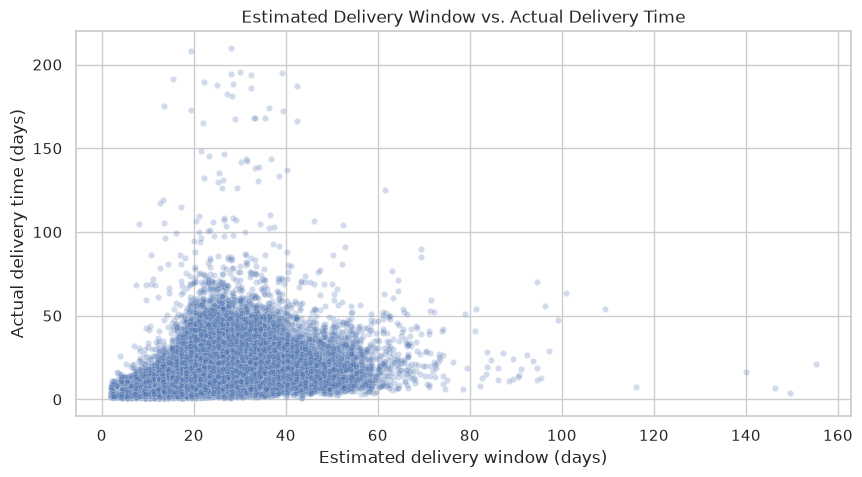

In [25]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=delivered_df,
    x="estimated_delivery_window_days",
    y="delivery_time_days",
    alpha=0.25,
    s=20,
)
plt.title("Estimated Delivery Window vs. Actual Delivery Time")
plt.xlabel("Estimated delivery window (days)")
plt.ylabel("Actual delivery time (days)")
plt.show()

**Insight:** The estimated delivery window contains substantial information about actual delivery time. This relationship motivated its use as an important feature in the downstream regression experiments.

## 10.4 Late Orders: Overall Rate

In [26]:
late_summary = (
    delivered_df["late_delivery"]
    .value_counts()
    .rename(index={0: "On time / early", 1: "Late"})
    .to_frame("orders")
)
late_summary["percentage"] = late_summary["orders"] / late_summary["orders"].sum() * 100
late_summary

,orders,percentage
late_delivery,,
On time / early,88649,91.89
Late,7827,8.11


### Class-imbalance implication

Late deliveries form a minority class. This becomes especially important in the secondary classification experiment, where accuracy alone can hide poor minority-class performance. Precision, recall, F1-score, ROC-AUC, and threshold behavior are therefore more informative.

## 10.5 Delivery Stage Durations

A delivery process can be decomposed into stages:

1. **Purchase → Approval**
2. **Approval → Carrier pickup**
3. **Carrier pickup → Customer delivery**

The stage analysis helps explain where time accumulates and which timestamps contain operational information.

In [27]:
stage_df = delivered_df.copy()
stage_df["purchase_to_approval_days"] = (
    stage_df["order_approved_at"] - stage_df["order_purchase_timestamp"]
).dt.total_seconds() / 86400
stage_df["approval_to_carrier_days"] = (
    stage_df["order_delivered_carrier_date"] - stage_df["order_approved_at"]
).dt.total_seconds() / 86400
stage_df["carrier_to_customer_days"] = (
    stage_df["order_delivered_customer_date"] - stage_df["order_delivered_carrier_date"]
).dt.total_seconds() / 86400

stage_cols = [
    "purchase_to_approval_days",
    "approval_to_carrier_days",
    "carrier_to_customer_days",
]
stage_df[stage_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
purchase_to_approval_days,"96,462.00",0.43,0.86,0.00,0.01,0.01,0.60,30.89
approval_to_carrier_days,"96,461.00",2.80,3.54,-171.22,0.87,1.82,3.58,125.76
carrier_to_customer_days,"96,475.00",9.33,8.76,-16.10,4.10,7.10,12.03,205.19


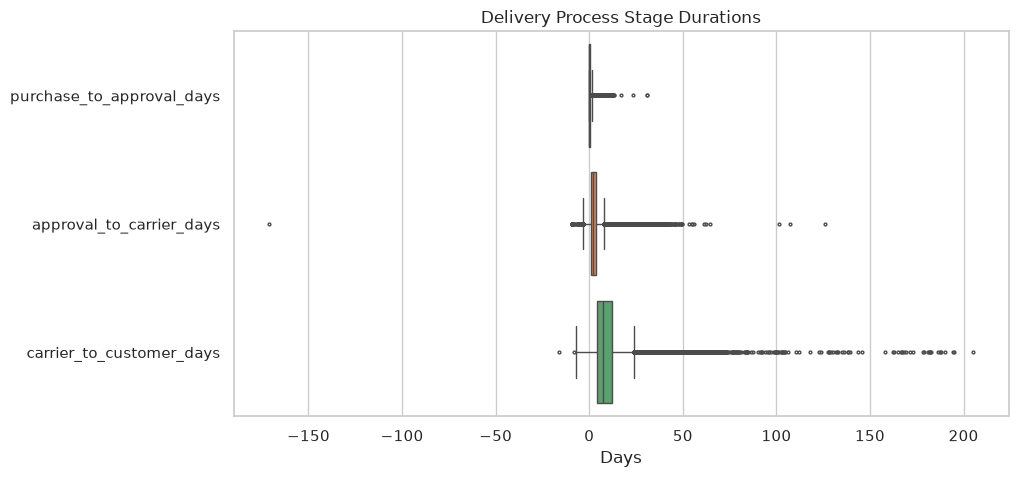

In [28]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=stage_df[stage_cols], orient="h", fliersize=2)
plt.title("Delivery Process Stage Durations")
plt.xlabel("Days")
plt.ylabel("")
plt.show()

**Caution:** These actual delivery-process timestamps are valuable for EDA and diagnosis, but they should **not automatically become prediction features**. A timestamp such as `order_delivered_customer_date` is part of the outcome itself and would leak future information if supplied to a model that is supposed to make a prediction before delivery.

# 11. Temporal Order Patterns

Time-derived features can reveal operational and behavioral patterns that are difficult to see from raw timestamps.

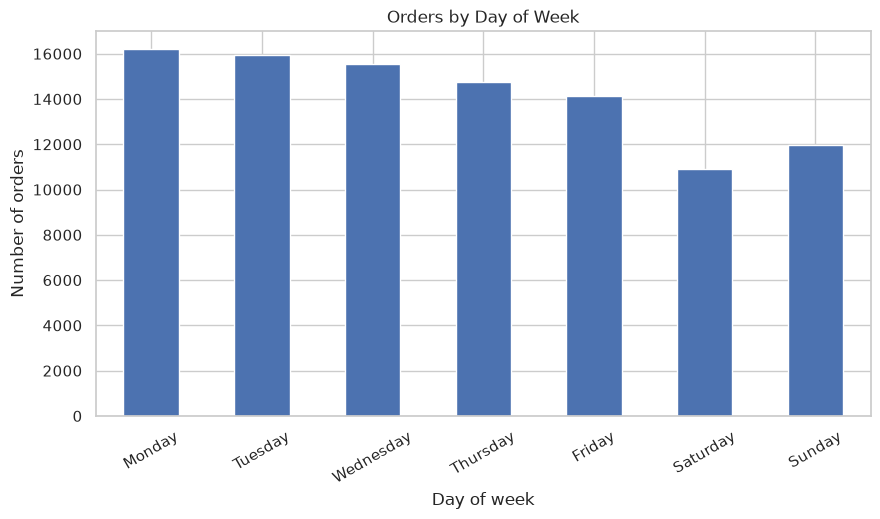

In [29]:
orders_temporal = order_level_df.copy()
orders_temporal["purchase_hour"] = orders_temporal["order_purchase_timestamp"].dt.hour
orders_temporal["purchase_day_of_week"] = orders_temporal["order_purchase_timestamp"].dt.day_name()
orders_temporal["purchase_month"] = orders_temporal["order_purchase_timestamp"].dt.month
orders_temporal["purchase_is_weekend"] = orders_temporal["order_purchase_timestamp"].dt.dayofweek >= 5

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_counts = orders_temporal["purchase_day_of_week"].value_counts().reindex(weekday_order)
weekday_counts.plot(kind="bar", figsize=(10, 5))
plt.title("Orders by Day of Week")
plt.xlabel("Day of week")
plt.ylabel("Number of orders")
plt.xticks(rotation=30)
plt.show()

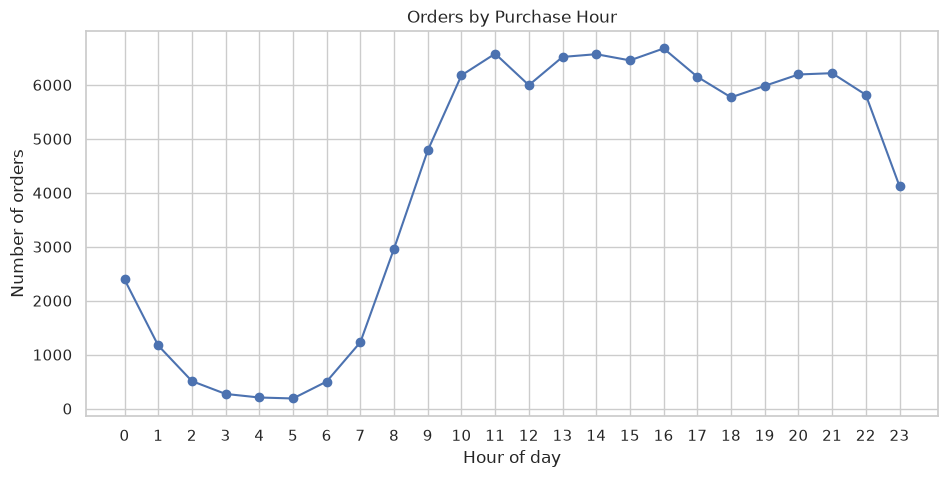

In [30]:
hour_counts = orders_temporal["purchase_hour"].value_counts().sort_index()
hour_counts.plot(kind="line", marker="o", figsize=(11, 5))
plt.title("Orders by Purchase Hour")
plt.xlabel("Hour of day")
plt.ylabel("Number of orders")
plt.xticks(range(0, 24))
plt.show()

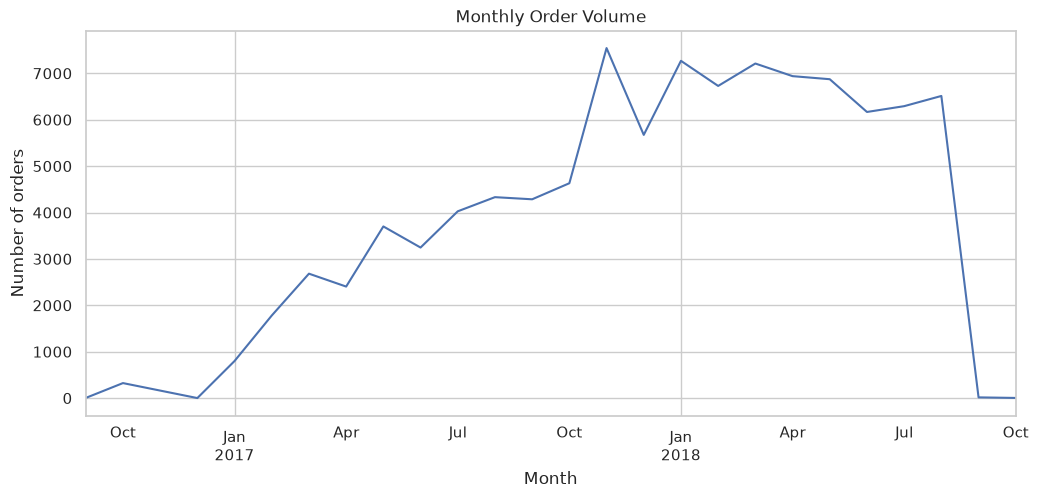

In [31]:
monthly_counts = orders_temporal.groupby(orders_temporal["order_purchase_timestamp"].dt.to_period("M")).size()
monthly_counts.plot(figsize=(12, 5))
plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of orders")
plt.show()

### Feature-engineering connection

The temporal analysis motivates features such as:

- `purchase_hour`
- `purchase_day_of_week`
- `purchase_month`
- `purchase_is_weekend`
- broader purchase-time intervals

These features are derived from information available at order creation time, unlike actual delivery timestamps.

# 12. Freight, Price & Item Count vs. Delivery Time

The objective here is not to prove causation. The goal is to identify useful relationships and candidate predictive variables.

In [32]:
analysis_cols = ["total_price", "total_freight", "item_count", "estimated_delivery_window_days", "delivery_time_days"]

delivered_df[analysis_cols].corr(numeric_only=True)["delivery_time_days"].sort_values(ascending=False)

delivery_time_days                1.00
estimated_delivery_window_days    0.38
total_freight                     0.17
total_price                       0.06
item_count                       -0.02
Name: delivery_time_days, dtype: float64

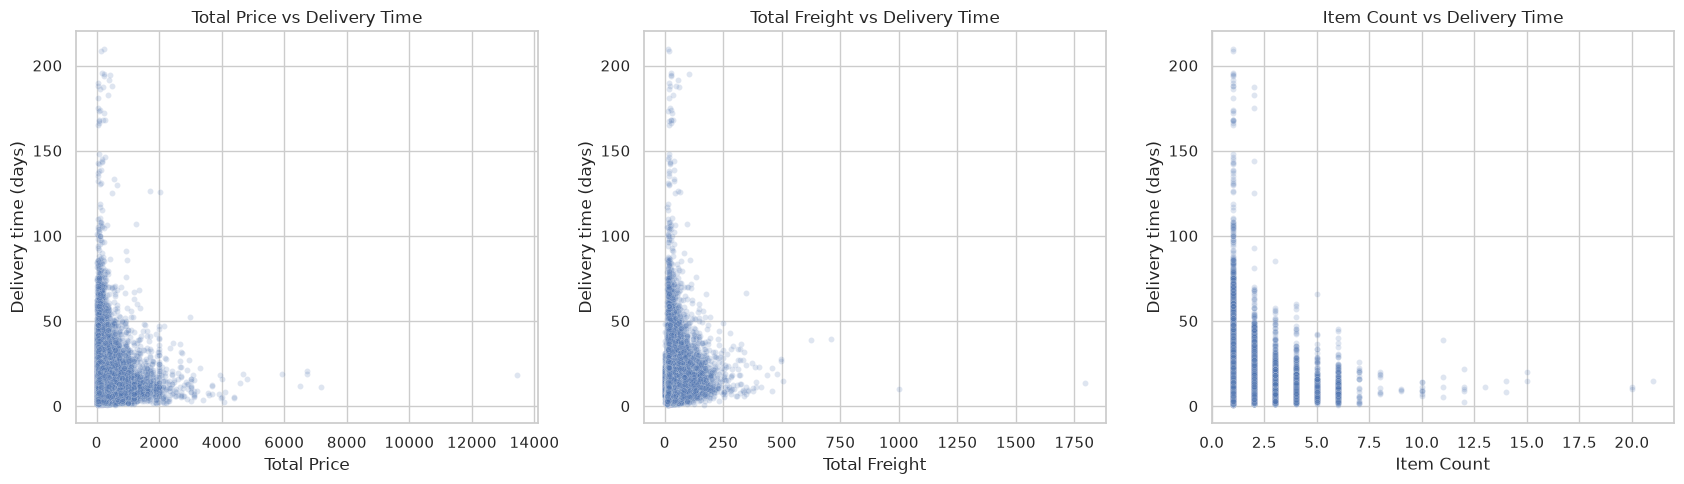

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, col in zip(axes, ["total_price", "total_freight", "item_count"]):
    sns.scatterplot(
        data=delivered_df,
        x=col,
        y="delivery_time_days",
        alpha=0.18,
        s=18,
        ax=ax,
    )
    ax.set_title(f"{col.replace('_', ' ').title()} vs Delivery Time")
    ax.set_xlabel(col.replace("_", " ").title())
    ax.set_ylabel("Delivery time (days)")

plt.tight_layout()
plt.show()

**Interpretation:** Correlation and scatterplots are screening tools, not causal evidence. A weak linear correlation does not mean a feature is useless for tree-based models, and a strong correlation does not guarantee that the feature is safe to use at prediction time.

# 13. Customer Reviews & Delivery Performance

Customer satisfaction is analyzed after delivery so that the relationship can be interpreted retrospectively. Reviews are not prediction features for the delivery-time model because they are only available after the customer experience occurs.

In [34]:
# Aggregate review scores to one record per order before joining.
review_by_order = (
    order_reviews_df
    .groupby("order_id", as_index=False)
    .agg(review_score=("review_score", "mean"))
)

delivery_review_df = delivered_df.merge(
    review_by_order,
    on="order_id",
    how="left",
    validate="one_to_one",
)

delivery_review_df.groupby("late_delivery")["review_score"].agg(["count", "mean", "median"])

,count,mean,median
late_delivery,,,
0,88168,4.29,5.00
1,7662,2.57,2.00


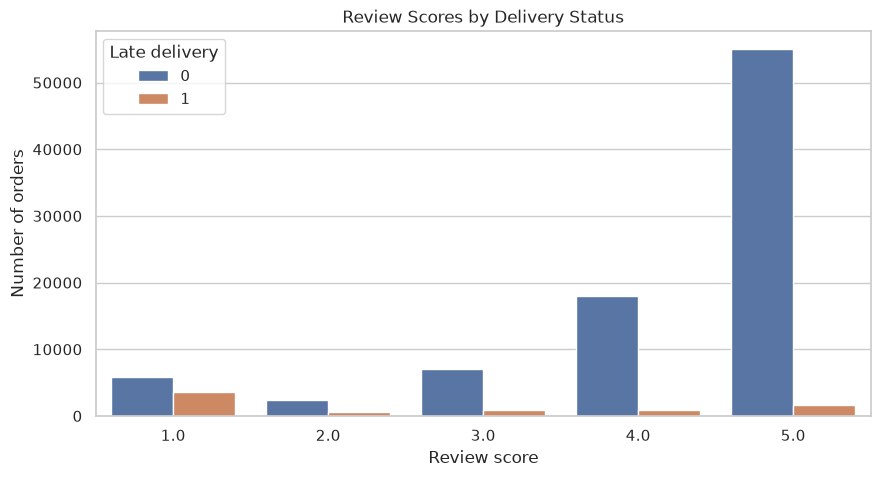

In [41]:
delivery_review_df['review_score'] = delivery_review_df['review_score'].round()

review_by_late = (
    delivery_review_df.groupby(["late_delivery", "review_score"])
    .size()
    .reset_index(name="orders")
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=review_by_late,
    x="review_score",
    y="orders",
    hue="late_delivery"
)
plt.title("Review Scores by Delivery Status")
plt.xlabel("Review score")
plt.ylabel("Number of orders")
plt.legend(title="Late delivery")
plt.show()

**Insight:** Delivery performance and customer satisfaction can be studied together as an outcome relationship. However, review score must remain out of any pre-delivery prediction feature set because it is post-outcome information.

# 14. Payment Behavior by City

Payment data can contain multiple rows per order (for example, installments or multiple payment records). To avoid treating each payment row as a separate order, the dominant payment type is first identified at the order level using total payment value.

In [36]:
payment_value_by_type = (
    order_payments_df
    .groupby(["order_id", "payment_type"], as_index=False)["payment_value"]
    .sum()
)

primary_payment = (
    payment_value_by_type
    .sort_values(["order_id", "payment_value"], ascending=[True, False])
    .drop_duplicates("order_id")
    [["order_id", "payment_type"]]
)

city_payment = order_level_df[["order_id", "customer_city"]].merge(
    primary_payment,
    on="order_id",
    how="left",
    validate="one_to_one",
)

city_payment_crosstab = pd.crosstab(city_payment["customer_city"], city_payment["payment_type"])
city_payment_crosstab.reindex(top_cities.index).fillna(0).sort_values(by="credit_card", ascending=False).head(10) if "credit_card" in city_payment_crosstab.columns else city_payment_crosstab.reindex(top_cities.index).fillna(0).head(10)

payment_type,boleto,credit_card,debit_card,not_defined,voucher
customer_city,,,,,
sao paulo,2783,11951,295,3,508
rio de janeiro,1123,5415,114,0,230
belo horizonte,468,2189,39,0,77
brasilia,394,1659,17,0,61
curitiba,336,1112,27,0,46
campinas,317,1051,28,0,48
porto alegre,286,1028,21,0,44
salvador,182,975,19,0,69
guarulhos,212,904,36,0,37


# 15. Products & Sellers

Product- and seller-level questions are kept separate from the order-level delivery dataset because they naturally live at a different granularity.

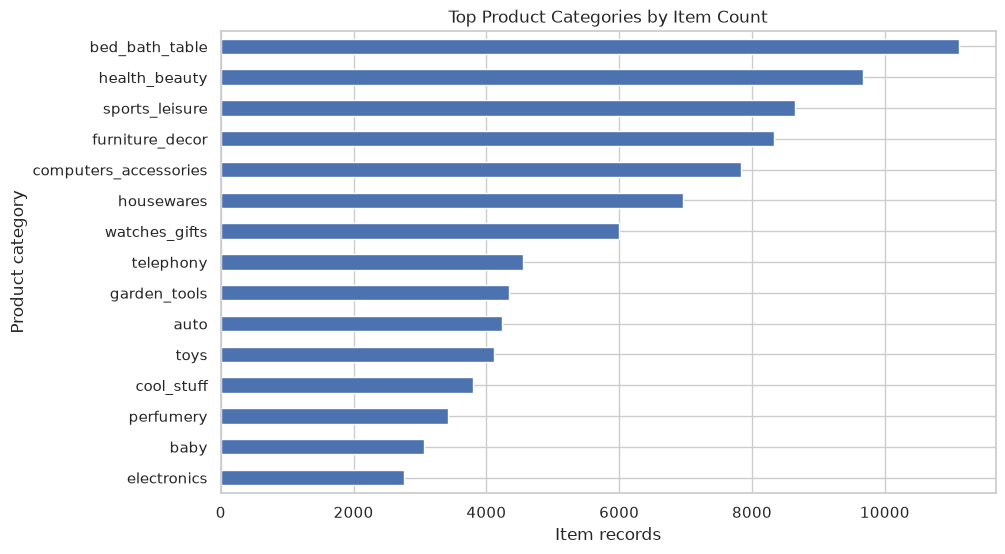

In [37]:
product_orders = order_items_df.merge(
    orders_df[["order_id", "customer_id"]],
    on="order_id",
    how="left",
).merge(
    cust_df[["customer_id", "customer_city"]],
    on="customer_id",
    how="left",
).merge(
    products_df[["product_id", "product_category_name"]],
    on="product_id",
    how="left",
).merge(
    product_cat_name_trans_df,
    on="product_category_name",
    how="left",
)

category_orders = (
    product_orders["product_category_name_english"]
    .value_counts()
    .head(15)
    .sort_values()
)

category_orders.plot(kind="barh", figsize=(10, 6))
plt.title("Top Product Categories by Item Count")
plt.xlabel("Item records")
plt.ylabel("Product category")
plt.show()

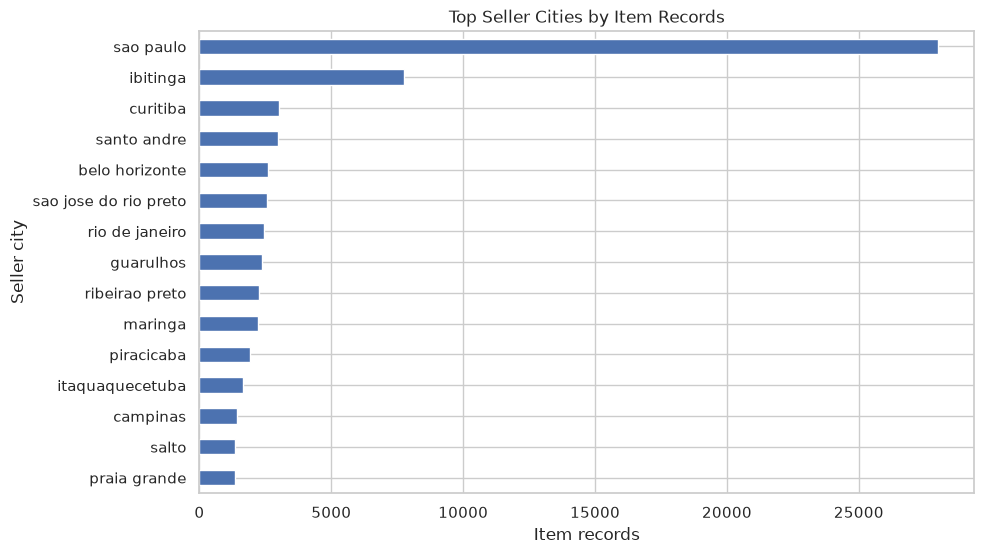

In [38]:
seller_items = order_items_df.merge(
    sellers_df[["seller_id", "seller_city", "seller_state"]],
    on="seller_id",
    how="left",
)

top_seller_cities = seller_items["seller_city"].value_counts().head(15).sort_values()
top_seller_cities.plot(kind="barh", figsize=(10, 6))
plt.title("Top Seller Cities by Item Records")
plt.xlabel("Item records")
plt.ylabel("Seller city")
plt.show()

# 16. Correlation Overview

A compact correlation matrix helps summarize numeric relationships before the modeling phase. It is descriptive only; it does not decide which features are safe or optimal for machine learning.

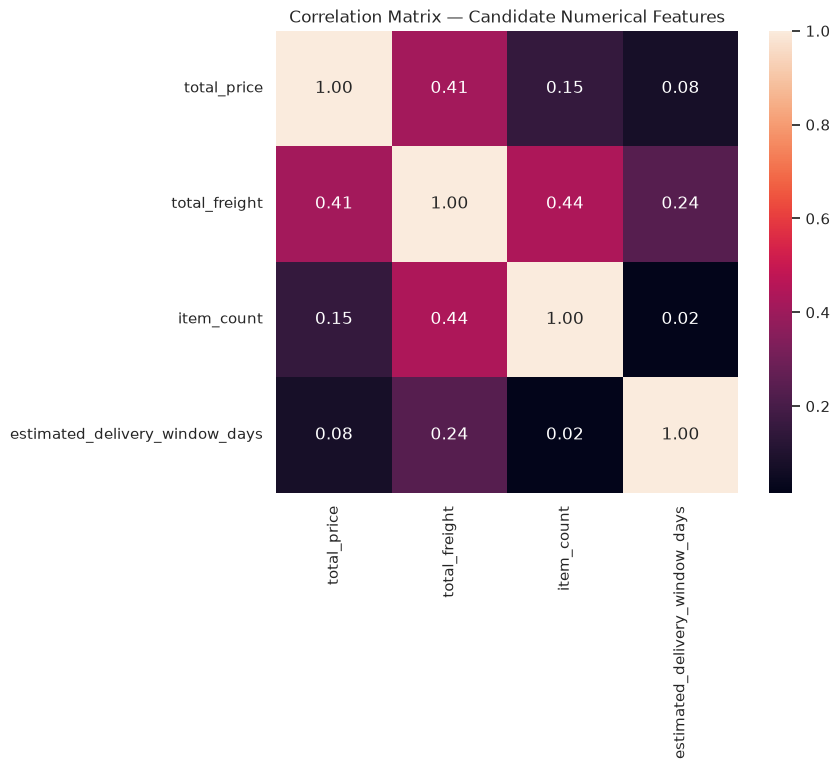

In [39]:
correlation_cols = [
    "total_price",
    "total_freight",
    "item_count",
    "estimated_delivery_window_days",
]

corr = order_level_df[correlation_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", square=True)
plt.title("Correlation Matrix — Candidate Numerical Features")
plt.show()

# 17. Key Findings

The exploratory analysis leads to several conclusions that guide the machine-learning stage.

### Delivery time
- Delivery time is strongly right-skewed, with a long tail of unusually slow orders.
- The extreme tail should be investigated and modeled deliberately rather than removed automatically.
- The estimated delivery window is strongly informative about actual delivery time.

### Geography
- Orders are concentrated in a subset of Brazilian cities and states.
- Geographic delivery behavior differs across regions, but rates from small samples should be interpreted cautiously.

### Order characteristics
- Price, freight, and item count show substantial skewness and outliers.
- These variables are plausible candidates for predictive modeling, but their contribution is not necessarily linear.

### Time
- Purchase hour, weekday, month, and weekend behavior show useful structure for feature engineering.

### Leakage awareness
- Actual delivery timestamps, review scores, and other post-delivery variables are useful for retrospective EDA but should not be used as predictors when the goal is to predict delivery before the outcome is known.

# 18. EDA → Machine Learning Handoff

The EDA suggests a modeling feature set based on information available at or near order creation:

| Feature family | Examples | Prediction-safe? |
|---|---|---|
| Purchase time | purchase hour, weekday, month, weekend | ✅ |
| Geography | customer state, city | ✅ |
| Order structure | total price, total freight, item count | ✅ |
| Promised delivery | estimated delivery window | ✅ |
| Actual delivery timestamps | delivered carrier/customer date | ❌ |
| Customer review | review score | ❌ |

The downstream regression task therefore uses pre-delivery information to predict **delivery time in days**, while the late-delivery classification experiment is treated as a secondary modeling problem.

# 19. Conclusion

This notebook transforms a set of relational Olist tables into a consistent order-level analytical dataset and investigates the operational factors surrounding delivery.

The most important modeling takeaway is that **good EDA is not just a collection of charts**. It is the reasoning layer between raw data and model design: it identifies data-granularity problems, missingness, skewness, outliers, useful temporal/geographic structure, and—critically—potential target leakage.

These findings feed directly into the feature-engineering, regression, classification, and hyperparameter-tuning stages of the project.